    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [25]:
inds_10 = pd.read_csv('csv/10_industry.csv')
inds_10['Date'] = pd.to_datetime(inds_10['Date'])
inds_10 = inds_10.set_index('Date')
inds_10.info()
inds_10

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   6539 non-null   float64
 1   Durbl   6539 non-null   float64
 2   Manuf   6539 non-null   float64
 3   Enrgy   6539 non-null   float64
 4   HiTec   6539 non-null   float64
 5   Telcm   6539 non-null   float64
 6   Shops   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Utils   6539 non-null   float64
 9   Other   6539 non-null   float64
dtypes: float64(10)
memory usage: 561.9 KB


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
2000-01-03,-1.65,-1.36,-2.49,-3.08,2.47,-1.26,-2.30,-0.58,-2.37,-3.31
2000-01-04,-1.81,-2.60,-2.68,-1.96,-5.34,-4.40,-3.28,-4.39,0.47,-3.68
2000-01-05,-0.13,-0.04,0.57,2.26,-1.09,0.01,-0.38,2.32,3.48,-0.38
2000-01-06,0.68,0.58,2.17,4.00,-4.93,-1.92,0.24,2.68,0.57,2.34
2000-01-07,2.11,4.81,3.21,1.16,3.51,0.93,4.27,7.61,1.13,1.99
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.36,0.00,0.46,-0.33,0.17,0.64,0.51,0.58,0.38,0.42
2025-12-26,-0.07,-1.65,-0.13,-0.30,0.09,-0.18,0.13,-0.05,-0.16,-0.05
2025-12-29,0.19,-2.68,-0.38,1.02,-0.40,0.43,-0.21,-0.26,0.26,-0.57


In [33]:
# ── 고정 파라미터 ──
gamma = 0.0    # regularization 제거
x_min = 0.0
x_max = 1.0   # box constraint 제거

N_STOCKS = len(inds_10.columns)

HORIZON    = 21
N          = HORIZON
M          = N_STOCKS   # 10
C          = 1.0
d          = 1.0
lam        = 0.7
delta      = 20          # risk aversion
HIDDEN_DIM = 128
EPOCHS     = 50
BATCH_SIZE = 16
LR         = 1e-4

# ── 실험 grid ──
LOOKBACK_LIST = [125, 252]
N1_LIST       = [0.3, 0.4, 0.5]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]

# configs:
# 1. LOOKBACK=125, n1=0.3  → INPUT_DIM=1250
# 2. LOOKBACK=125, n1=0.4  → INPUT_DIM=1250
# 3. LOOKBACK=125, n1=0.5  → INPUT_DIM=1250
# 4. LOOKBACK=252, n1=0.3  → INPUT_DIM=2520
# 5. LOOKBACK=252, n1=0.4  → INPUT_DIM=2520
# 6. LOOKBACK=252, n1=0.5  → INPUT_DIM=2520


In [27]:
inds_10 = inds_10.sort_index()   # ← 이 한 줄 추가
inds_10 = inds_10[~inds_10.index.duplicated(keep='first')]  # ← 없음
inds_10 = inds_10 / 100.0

stock_names = inds_10.columns.tolist()

# =============================================================================
# 2. IS / OOS 분리 (날짜 기준)
# =============================================================================
IS_START = "2000-01-01"
IS_END   = "2017-12-31"
BT_START = "2018-01-01"
BT_END   = "2025-12-31"

is_df = inds_10[IS_START : IS_END]
bt_df = inds_10[BT_START : BT_END]

is_np  = is_df.values
bt_np  = bt_df.values

N_IS   = len(is_df)
N_BT   = len(bt_df)
N_DAYS = len(inds_10)

print(f"전체 : {inds_10.index[0].date()} → {inds_10.index[-1].date()}  ({N_DAYS} days)")
print(f"IS   : {is_df.index[0].date()} → {is_df.index[-1].date()}  ({N_IS} days)")
print(f"BT   : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목 : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
is_mean = is_np.mean(axis=0)   # shape (10,)
is_std  = is_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (lookback, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # IS 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

full_np      = np.vstack([is_np, bt_np])
BT_START_IDX = N_IS

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]
    INPUT_DIM = LOOKBACK * N_STOCKS   # ← LOOKBACK마다 달라짐

    # make_windows도 루프 안에서 호출
    is_samples = make_windows(is_np, LOOKBACK, HORIZON,
                              start=LOOKBACK, end=N_IS)

    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    print(f"\n[LOOKBACK={LOOKBACK}, n1={n1}]")
    print(f"  IS 학습 샘플 수  : {len(is_samples)}")
    print(f"  BT 리밸런싱 횟수 : {len(rebal_samples)}")

전체 : 2000-01-03 → 2025-12-31  (6539 days)
IS   : 2000-01-03 → 2017-12-29  (4528 days)
BT   : 2018-01-02 → 2025-12-31  (2011 days)
종목 : ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

[LOOKBACK=125, n1=0.3]
  IS 학습 샘플 수  : 4383
  BT 리밸런싱 횟수 : 95

[LOOKBACK=125, n1=0.4]
  IS 학습 샘플 수  : 4383
  BT 리밸런싱 횟수 : 95

[LOOKBACK=125, n1=0.5]
  IS 학습 샘플 수  : 4383
  BT 리밸런싱 횟수 : 95

[LOOKBACK=252, n1=0.3]
  IS 학습 샘플 수  : 4256
  BT 리밸런싱 횟수 : 95

[LOOKBACK=252, n1=0.4]
  IS 학습 샘플 수  : 4256
  BT 리밸런싱 횟수 : 95

[LOOKBACK=252, n1=0.5]
  IS 학습 샘플 수  : 4256
  BT 리밸런싱 횟수 : 95


In [28]:
def plot_multi_pnl(results_list, figsize=(14, 8)):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"height_ratios": [3, 1]},
                                   sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    for (bt_results, label), color in zip(results_list, colors):
        pv = [1.0]
        for res in bt_results:
            w    = res["w_real"]
            base = pv[-1]
            pv.extend((base * (1 + w)).tolist())

        pv          = np.array(pv)
        running_max = np.maximum.accumulate(pv)
        drawdown    = (running_max - pv) / (running_max + 1e-10)
        total_ret   = pv[-1] - 1.0
        max_dd      = drawdown.max()
        calmar      = total_ret / (max_dd + 1e-10)

        full_label = f"{label}  R:{total_ret:.1%}  MDD:{max_dd:.1%}  Cal:{calmar:.2f}"
        ax1.plot(np.arange(len(pv)), pv, color=color, linewidth=1.5, label=full_label)
        ax2.plot(np.arange(len(pv)), -drawdown * 100, color=color, linewidth=1.0, alpha=0.7)

    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title("Cumulative PnL Comparison")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.25)

    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()




  Config: LOOKBACK=125, n1=0.3

── IS Training ──
  Epoch   1/50  loss = 0.013276


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/diffcp/cone_program.py:522: UserWarning: Solved/Inaccurate.
  warnings.warn("Solved/Inaccurate.")


  Epoch   5/50  loss = 0.007496
  Epoch  10/50  loss = 0.004724
  Epoch  15/50  loss = 0.002956
  Epoch  20/50  loss = 0.004622
  Epoch  25/50  loss = 0.002377
  Epoch  30/50  loss = 0.002389
  Epoch  35/50  loss = 0.002482
  Epoch  40/50  loss = 0.002139
  Epoch  45/50  loss = 0.001662
  Epoch  50/50  loss = 0.000934

── Backtest : DFL-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 727.05it/s]

    1    0.0197   1.1154%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
    2   -0.0580   6.7162%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
    3   -0.0217   6.5662%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
    4   -0.0579   8.5517%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': -0.0}
    5    0.0258   0.8778%  {'NoDur': 0.85, 'Durbl': 0.15, 'Utils': 0.0}
    6    0.0381   1.0126%  {'NoDur': 1.0, 'Durbl': 0.0, 'Utils': 0.0}
    7    0.0226   0.9972%  {'NoDur': 1.0, 'Durbl': 0.0, 'Utils': 0.0}
    8    0.0001   2.4492%  {'NoDur': 0.843, 'Durbl': 0.157, 'Utils': 0.0}
    9    0.0058   2.1310%  {'NoDur': 1.0, 'Utils': 0.0, 'Shops': 0.0}
   10    0.0116   4.2530%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
   11   -0.0124   4.2706%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': -0.0}
   12   -0.0964  15.8048%  {'Durbl': 0.542, 'Utils': 0.224, 'NoDur': 0.206}
   13    0.0725   1.7512%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
   14    0.0149   1.7376%  {'NoDur': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
   15 

...

Backtesting: 100%|██████████| 95/95 [00:00<00:00, 733.41it/s]

    1   -0.0281   3.6241%  {'Utils': 1.0, 'Hlth': 0.0, 'Durbl': -0.0}
    2   -0.0468   5.9520%  {'Utils': 1.0, 'Durbl': 0.0, 'Hlth': 0.0}
    3    0.0295   2.7236%  {'Utils': 1.0, 'Hlth': 0.0, 'Durbl': -0.0}
    4   -0.0050   4.8743%  {'Durbl': 0.961, 'Manuf': 0.039, 'Hlth': 0.0}
    5    0.0460   2.5619%  {'Durbl': 1.0, 'Hlth': 0.0, 'Utils': 0.0}
    6    0.0076   2.9633%  {'Hlth': 1.0, 'Utils': 0.0, 'Durbl': 0.0}
    7    0.0035   2.5027%  {'Utils': 1.0, 'Hlth': 0.0, 'Durbl': 0.0}
    8    0.0308   0.6499%  {'Utils': 0.508, 'Hlth': 0.492, 'Durbl': -0.0}
    9    0.0061   1.6791%  {'Hlth': 0.506, 'Utils': 0.494, 'Durbl': 0.0}
   10    0.0088   3.3421%  {'Utils': 1.0, 'Hlth': 0.0, 'Manuf': -0.0}
   11    0.0630   3.4240%  {'Durbl': 1.0, 'Hlth': 0.0, 'Utils': 0.0}
   12   -0.0496   9.5539%  {'Utils': 0.972, 'Durbl': 0.028, 'Hlth': 0.0}
   13    0.0902   2.1381%  {'Hlth': 0.518, 'Durbl': 0.482, 'Utils': 0.0}
   14    0.0240   1.6063%  {'Durbl': 0.586, 'Hlth': 0.29, 'Utils': 0.124}
   15


── IS Training ──
  Epoch   1/50  loss = 0.006456
  Epoch   5/50  loss = 0.006822
  Epoch  10/50  loss = 0.006351
  Epoch  15/50  loss = 0.006358
  Epoch  20/50  loss = 0.006360
  Epoch  25/50  loss = 0.006285
  Epoch  30/50  loss = 0.008721
  Epoch  35/50  loss = 0.006996
  Epoch  40/50  loss = 0.006996
  Epoch  45/50  loss = 0.006996
  Epoch  50/50  loss = 0.006960

── Backtest : DFL-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 735.51it/s]

    1    0.0627   3.4085%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
    2   -0.0314   8.3176%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
    3   -0.0388   8.6416%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
    4    0.0057   2.7258%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': 0.0}
    5    0.0458   1.1381%  {'Hlth': 1.0, 'Durbl': 0.0, 'Shops': -0.0}
    6    0.0076   2.9633%  {'Hlth': 1.0, 'Durbl': 0.0, 'Other': -0.0}
    7    0.0572   1.5505%  {'Hlth': 1.0, 'Durbl': 0.0, 'Shops': -0.0}
    8    0.0397   0.7231%  {'Hlth': 1.0, 'Durbl': 0.0, 'Enrgy': -0.0}
    9    0.0220   1.1286%  {'Hlth': 1.0, 'Durbl': 0.0, 'NoDur': -0.0}
   10   -0.0894  10.0994%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
   11    0.0495   4.1353%  {'Hlth': 1.0, 'Durbl': 0.0, 'Shops': -0.0}
   12   -0.0773  15.8959%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
   13    0.0685   3.2112%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
   14    0.0328   1.3117%  {'Hlth': 1.0, 'Durbl': 0.0, 'Utils': -0.0}
   15    0.0029   2.1

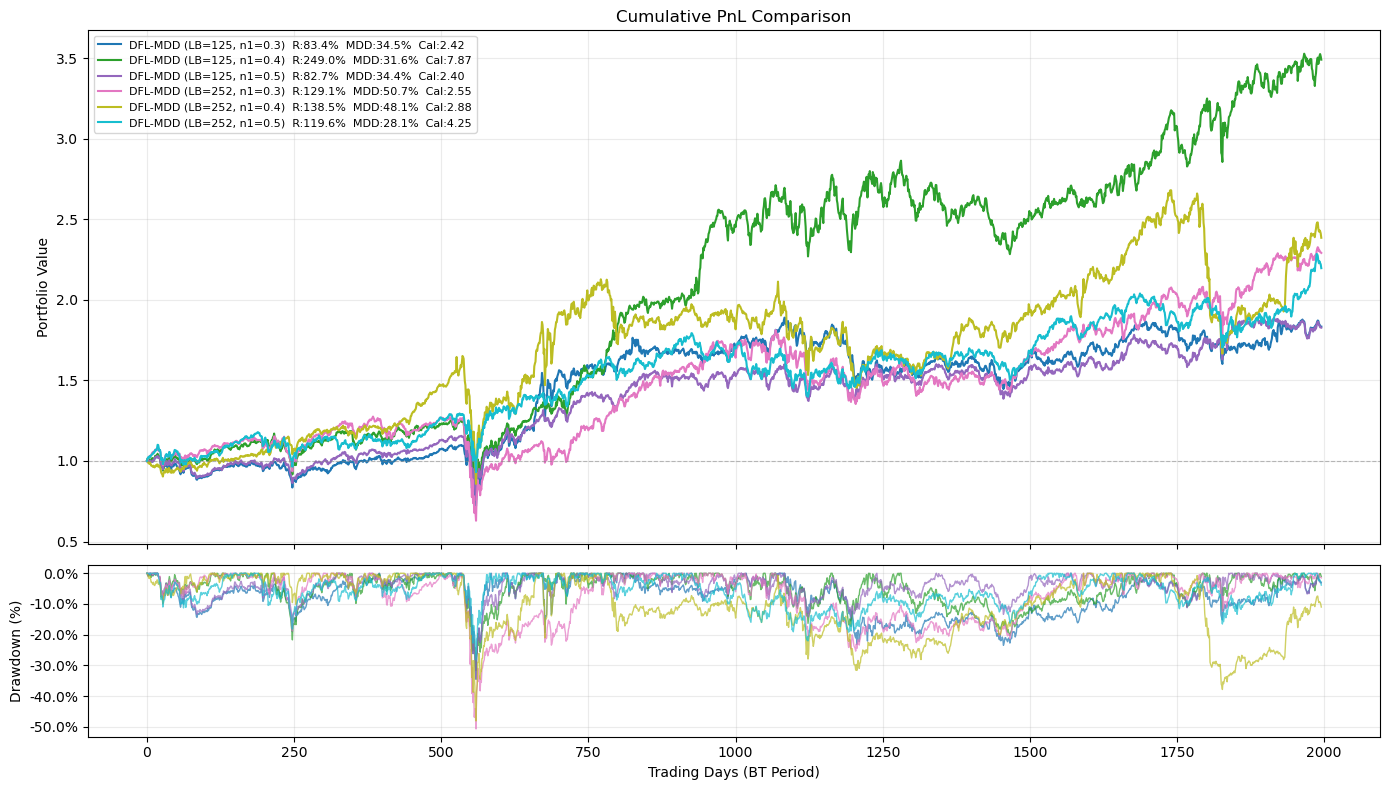

In [29]:
import importlib
import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass, backtest_dfl_mdd, plot_pnl,
)

all_results_dfl_mdd = []

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
    print(f"{'='*60}")

    INPUT_DIM = LOOKBACK * N_STOCKS

    is_samples    = make_windows(is_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_IS)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    opt_layer  = build_optimization_layer(N, M, gamma, delta=delta)   # delta 반영
    optimizer  = optim.Adam(pred_model.parameters(), lr=LR, weight_decay=1e-4)

    zs_is = torch.tensor(np.array([s[0] for s in is_samples]), dtype=torch.float32)
    rs_is = torch.tensor(np.array([s[1] for s in is_samples]), dtype=torch.float32)

    print("\n── IS Training ──")
    pred_model.train()

    for epoch in range(EPOCHS):
        perm    = torch.randperm(len(is_samples))
        ep_loss = []
        for i in range(0, len(is_samples), BATCH_SIZE):
            idx = perm[i : i + BATCH_SIZE]
            z_b, r_b = zs_is[idx], rs_is[idx]
            optimizer.zero_grad()
            result = forward_pass(
                z_b, r_b, pred_model, opt_layer,
                n1, C, d, x_min, x_max, lam,
                is_mean=is_mean, is_std=is_std, delta=delta,   # delta / Sigma 반영
            )
            result["loss"].backward()
            optimizer.step()
            ep_loss.append(result["loss"].item())
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")

    bt_dfl_mdd = backtest_dfl_mdd(
        pred_model=pred_model, opt_layer=opt_layer,
        rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
        n1=n1, x_min=x_min, x_max=x_max,
        delta=delta, is_mean=is_mean, is_std=is_std,           # delta / Sigma 반영
        stock_names=stock_names,
    )
    all_results_dfl_mdd.append((bt_dfl_mdd, f"DFL-MDD (LB={LOOKBACK}, n1={n1})"))

plot_multi_pnl(all_results_dfl_mdd)



  Config: LOOKBACK=125, n1=0.3

── PTO-MDD Training (MSE) ──
  Epoch   1/50  mse = 0.003140
  Epoch   5/50  mse = 0.000218
  Epoch  10/50  mse = 0.000187
  Epoch  15/50  mse = 0.000187
  Epoch  20/50  mse = 0.000187
  Epoch  25/50  mse = 0.000187
  Epoch  30/50  mse = 0.000187
  Epoch  35/50  mse = 0.000187
  Epoch  40/50  mse = 0.000187
  Epoch  45/50  mse = 0.000187
  Epoch  50/50  mse = 0.000187

── Backtest : PTO-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------
    1    0.0300   2.1781%  {'NoDur': 0.524, 'Enrgy': 0.297, 'Hlth': 0.179}
    2   -0.0671   8.7435%  {'NoDur': 0.543, 'Enrgy': 0.295, 'Hlth': 0.162}
    3   -0.0128   5.2577%  {'NoDur': 0.594, 'Enrgy': 0.252, 'Hlth': 0.155}
    4   -0.0108   5.0280%  {'NoDur': 0.621, 'Enrgy': 0.254, 'Hlth': 0.125}
    5    0.0300   1.3604%  {'NoDur': 0.616, 'Enrgy': 0.262, 'Hlth': 0.122}
    6    0.0219   0.7021%  {'NoDur': 0.633, 'Enrgy': 0.238, 'Hlth': 0.129}
    7    0.0252

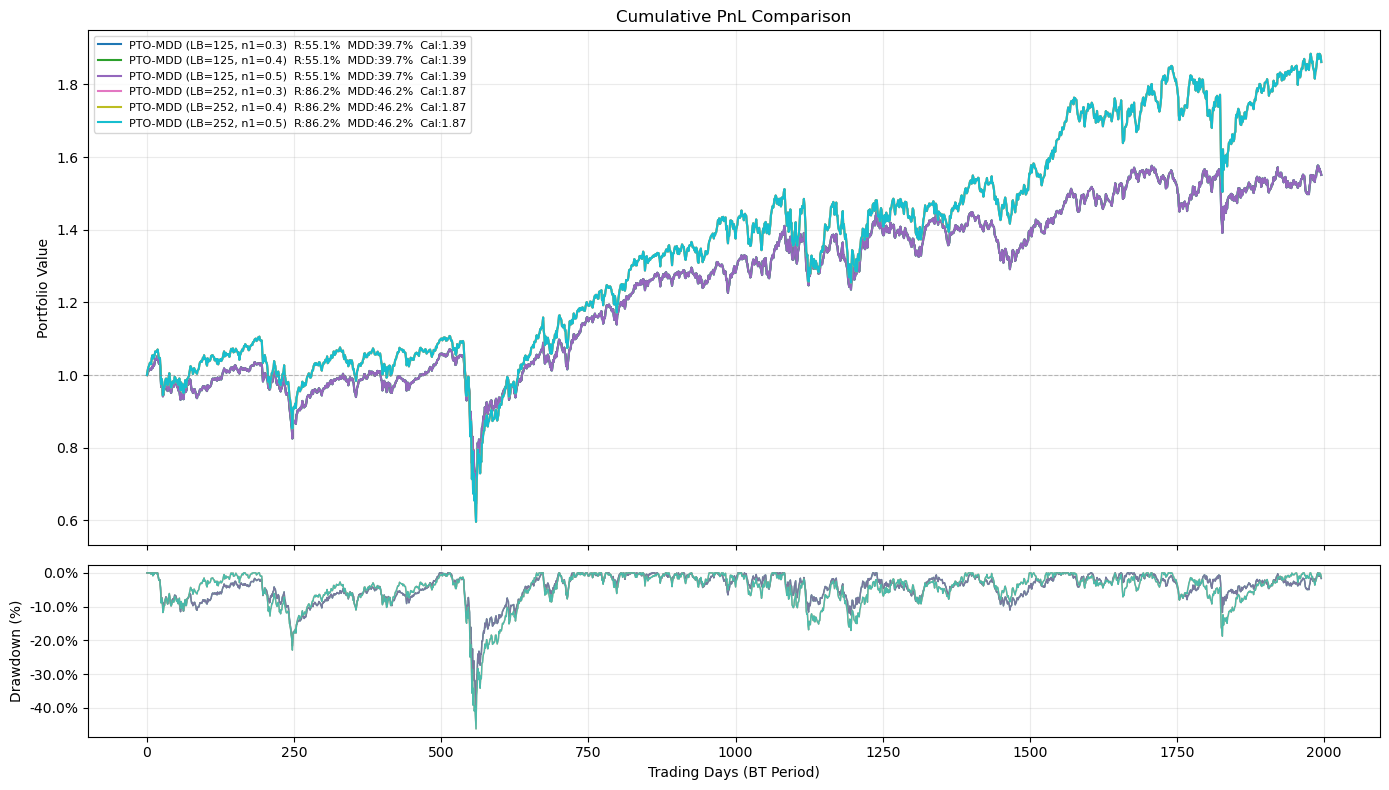

In [34]:
import importlib
import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd import train_pto_mdd, backtest_pto_mdd


all_results_pto_mdd = []

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={LOOKBACK}, n1={n1}")
    print(f"{'='*60}")

    INPUT_DIM = LOOKBACK * N_STOCKS

    is_samples    = make_windows(is_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_IS)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)

    bt_pto_mdd = backtest_pto_mdd(
        model_pto_mdd, rebal_samples, N, d, C,
        n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
        delta=delta,          # risk aversion 파라미터
        is_mean=is_mean,      # Sigma 추정용
        is_std=is_std,
        stock_names=stock_names,   # STOCK_NAMES → stock_names 수정
    )

    all_results_pto_mdd.append((bt_pto_mdd, f"PTO-MDD (LB={LOOKBACK}, n1={n1})"))

plot_multi_pnl(all_results_pto_mdd)



  Config: LOOKBACK=125

── PTO-MVO Training (MSE) ──
  Epoch   1/50  mse = 0.003140
  Epoch   5/50  mse = 0.000218
  Epoch  10/50  mse = 0.000187
  Epoch  15/50  mse = 0.000187
  Epoch  20/50  mse = 0.000187
  Epoch  25/50  mse = 0.000187
  Epoch  30/50  mse = 0.000187
  Epoch  35/50  mse = 0.000187
  Epoch  40/50  mse = 0.000187
  Epoch  45/50  mse = 0.000187
  Epoch  50/50  mse = 0.000187

── Backtest : PTO-MVO ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------
    1    0.0347   1.7596%  {'NoDur': 0.18, 'Utils': 0.156, 'Enrgy': 0.132}
    2   -0.0545   7.9860%  {'NoDur': 0.196, 'Utils': 0.168, 'Enrgy': 0.122}
    3   -0.0101   4.7909%  {'NoDur': 0.227, 'Utils': 0.227, 'Shops': 0.123}
    4    0.0033   2.7558%  {'Utils': 0.279, 'NoDur': 0.258, 'Shops': 0.094}
    5    0.0173   0.7718%  {'Utils': 0.305, 'NoDur': 0.248, 'Enrgy': 0.089}
    6    0.0268   0.3944%  {'Utils': 0.306, 'NoDur': 0.255, 'Shops': 0.09}
    7    0.0205   0

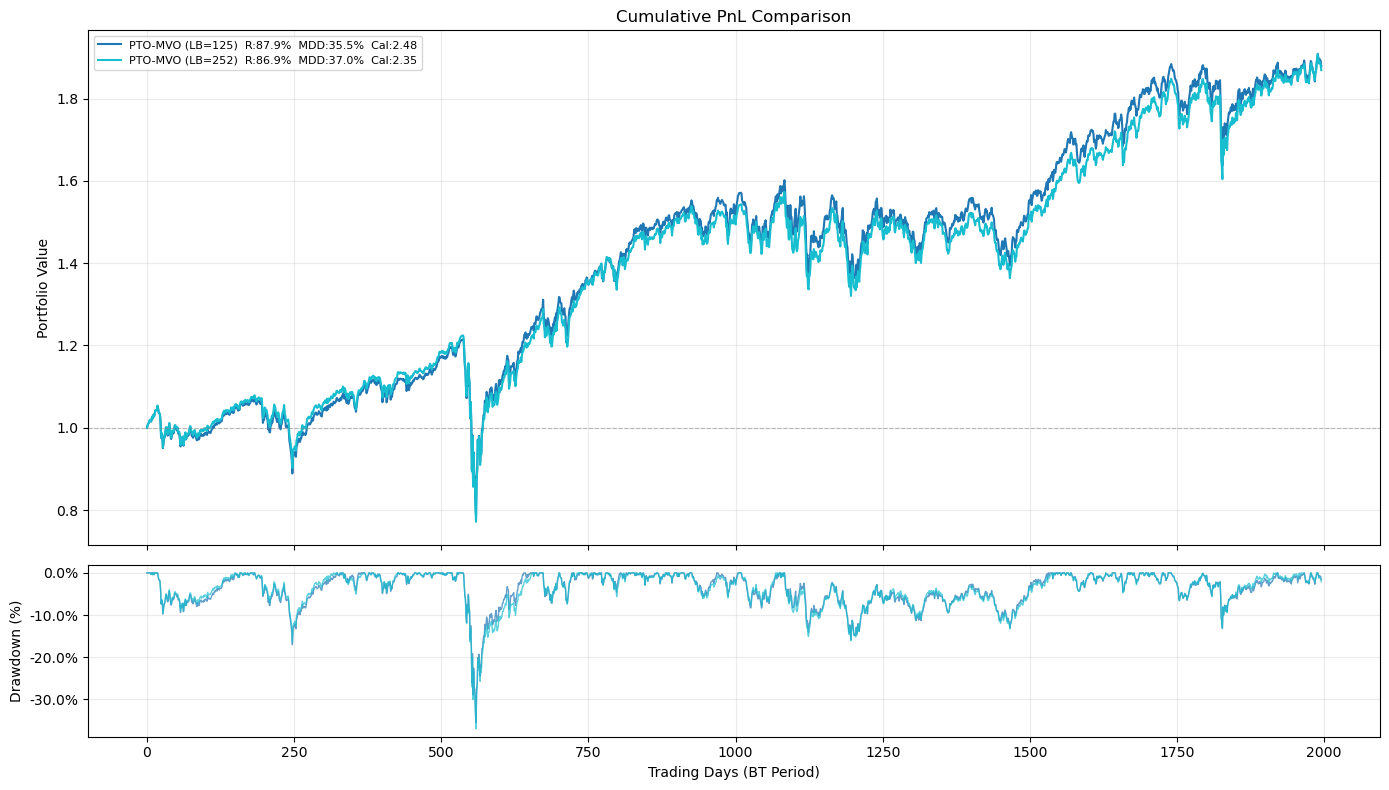

In [35]:
import importlib
import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo import train_pto_mvo, backtest_pto_mvo

all_results_mvo = []

for lookback in LOOKBACK_LIST:

    print(f"\n{'='*60}")
    print(f"  Config: LOOKBACK={lookback}")
    print(f"{'='*60}")

    INPUT_DIM = lookback * N_STOCKS

    is_samples    = make_windows(is_np, lookback, HORIZON,
                                 start=lookback, end=N_IS)
    rebal_samples = make_windows(full_np, lookback, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::HORIZON]

    torch.manual_seed(42)

    model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
    train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)

    bt_pto_mvo = backtest_pto_mvo(
        model_pto_mvo, rebal_samples, N, d, C,
        delta=delta,                    # lam_mvo → delta 수정
        x_min=x_min, x_max=x_max, gamma=gamma,
        is_mean=is_mean, is_std=is_std,
        stock_names=stock_names,
    )
    all_results_mvo.append((bt_pto_mvo, f"PTO-MVO (LB={lookback})"))

plot_multi_pnl(all_results_mvo)
